In [60]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import mpltern
import warnings
import biotite.structure as struc
import biotite.structure.io.pdb as pdb  # ✅ 正确的引用方式
import matplotlib.ticker as ticker  # <--- 【Step 0】必须引入这个库

In [61]:
import matplotlib.pyplot as plt

# ==========================================
# 0. 全局字体与样式设置 (关键步)
# ==========================================
# 设置全局字体大小，8-10pt 是学术图表的标准
plt.rcParams.update({
    'font.size': 9,           # 默认字号
    'axes.titlesize': 10,     # 子图标题字号
    'axes.labelsize': 9,      # 坐标轴标签字号
    'legend.fontsize': 8,     # 图例字号
    'xtick.labelsize': 8,     # 刻度字号
    'ytick.labelsize': 8,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'], # 期刊常用字体
    'pdf.fonttype': 42,       # 确保 PDF 导出时字体可编辑
    'ps.fonttype': 42
})

In [62]:
import matplotlib.pyplot as plt

# 替换之前的 rcParams 设置
plt.rcParams.update({
    'font.family': 'sans-serif',
    # 按顺序查找：Arial, 然后是常见的替代品，最后是通用无衬线
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans', 'sans-serif'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# 这里计算群PDB数据集中sheet、helix、loop的比例

在 /root/REFER_PDB 中找到 50 个 PDB 文件，开始解析...
成功解析 50 个文件。
生成模拟的'模型生成数据'用于右图演示...
在 /workspace/zhangzh/evodiff-main/output/ESM2_align_exp22_oadm_molt5_cross_attn/gent_seq/OmegaFold 中找到 580 个 PDB 文件，开始解析...
成功解析 580 个文件。
警告: 你的中心点 (0.3, 0.0, 0.5) 加起来不等于 1，可能会导致定位偏离！
正在聚焦中心 (0.3, 0.0, 0.5), 半径 0.1...
计算出的裁剪参数: Helix_min=0.20, Sheet_min=0.00, Loop_min=0.40
警告: 你的中心点 (0.3, 0.0, 0.5) 加起来不等于 1，可能会导致定位偏离！
正在聚焦中心 (0.3, 0.0, 0.5), 半径 0.1...
计算出的裁剪参数: Helix_min=0.20, Sheet_min=0.00, Loop_min=0.40
绘图完成，正在显示...


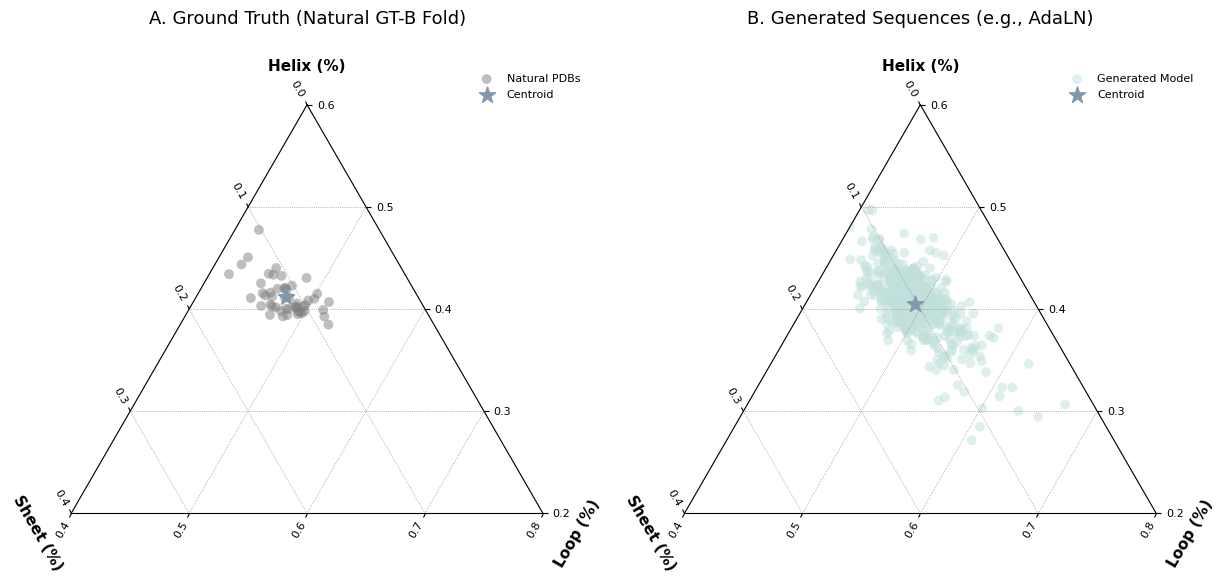

In [23]:
# ==========================================
# 1. 纯 Python PDB 解析器 (稳健，不报错)
# ==========================================
def parse_pdb_header_for_ss_ratios(pdb_file):
    """
    针对 OmegaFold/AlphaFold 优化：
    使用 Biotite 根据 3D 坐标计算二级结构 (DSSP)。
    修复了 filter_amino_acids 的调用方式。
    """
    try:
        # 1. 读取 PDB 文件
        file = pdb.PDBFile.read(pdb_file)
        
        # 2. 获取原子结构 (model=1)
        if file.get_model_count() > 0:
            array = file.get_structure(model=1)
        else:
            array = file.get_structure()
            
        # 3. 过滤出氨基酸原子 (修正点：使用模块函数，而不是对象方法)
        # 这一步是为了去除水分子、配体等非蛋白原子
        mask = struc.filter_amino_acids(array)
        array = array[mask]
        
        # 如果文件为空
        if array.array_length() == 0:
            return None

        # 4. 核心步骤：计算二级结构
        # 返回数组: 'a'=Helix, 'b'=Sheet, 'c'=Loop
        sse = struc.annotate_sse(array)
        
        # 5. 统计比例
        n_total = len(sse)
        if n_total == 0: return None
        
        n_helix = np.sum(sse == 'a')
        n_sheet = np.sum(sse == 'b')
        n_loop  = np.sum(sse == 'c')
        
        return n_helix/n_total, n_sheet/n_total, n_loop/n_total

    except Exception as e:
        # 如果还有其他问题（比如缺少 backbone 原子），会打印出来
        print(f"解析出错 {pdb_file}: {e}")
        return None


        
def get_ss_ratios_batch(pdb_dir):
    """批量处理文件夹"""
    pdb_files = glob.glob(os.path.join(pdb_dir, "*.pdb"))
    print(f"在 {pdb_dir} 中找到 {len(pdb_files)} 个 PDB 文件，开始解析...")
    
    h_list, s_list, l_list = [], [], []
    valid_count = 0
    for pdb in pdb_files:
        res = parse_pdb_header_for_ss_ratios(pdb)
        if res:
            h, s, l = res
            # 简单过滤掉完全没解析出结构的文件
            if h+s+l > 0:
                h_list.append(h)
                s_list.append(s)
                l_list.append(l)
                valid_count += 1
            else:
                print(f"警告: {os.path.basename(pdb)} 解析为空，跳过。")
    
    print(f"成功解析 {valid_count} 个文件。")
    # 转换为 numpy 数组并转置，方便绘图输入
    return np.array(h_list), np.array(s_list), np.array(l_list)

def set_ternary_zoom(ax, center, radius=0.1):
    """
    手动聚焦到指定中心点。
    
    参数:
    ax: 绘图轴
    center: (helix, sheet, loop) 的元组，例如 (0.1, 0.8, 0.1) -> 必须加起来等于 1.0
    radius: 显示半径。越小放得越大。例如 0.1 表示显示中心周围 +/- 10% 的区域
    """
    c_h, c_s, c_l = center
    
    # 简单的数学检查
    if abs((c_h + c_s + c_l) - 1.0) > 0.05:
        print(f"警告: 你的中心点 {center} 加起来不等于 1，可能会导致定位偏离！")

    # 计算裁剪边界 (min values)
    # 逻辑：如果我们想让中心点在正中间，我们需要切掉边缘
    # 这里的 min 值是指：坐标轴从哪里开始显示
    t_min = max(0, c_h - radius) # Helix 最小值
    l_min = max(0, c_s - radius) # Sheet 最小值
    r_min = max(0, c_l - radius) # Loop 最小值

    # 再次检查边界合法性 (和必须 < 1)
    if t_min + l_min + r_min >= 1.0:
        print("错误: 放大倍数太大(radius太小)或中心点太偏，导致计算出的边界无效。")
        return

    print(f"正在聚焦中心 {center}, 半径 {radius}...")
    print(f"计算出的裁剪参数: Helix_min={t_min:.2f}, Sheet_min={l_min:.2f}, Loop_min={r_min:.2f}")
    
    # 应用设置
    ax.set_ternary_min(t_min, l_min, r_min)


# ==========================================
# 2. 绘图辅助函数
# ==========================================
def plot_single_scatter(ax, h, s, l, color, label, title, show_centroid=True):
    """在指定的 ax 上绘制单个三角散点图"""
    # 确保数据归一化 (mpltern 需要)
    total = h + s + l
    # 避免除以零
    mask = total > 0
    h, s, l = h[mask]/total[mask], s[mask]/total[mask], l[mask]/total[mask]

    set_ternary_zoom(ax, center=(0.3, 0.0, 0.5), radius=0.1)
    # 1. 绘制散点
    # 顺序: Top(Helix), Left(Sheet), Right(Loop)
    ax.scatter(h, s, l, color=color, alpha=0.5, s=50, edgecolors='none', label=label)
    

    # 2. 绘制重心 (五角星)
    if show_centroid and len(h) > 0:
        mean_h, mean_s, mean_l = np.mean(h), np.mean(s), np.mean(l)
        norm = mean_h + mean_s + mean_l
        ax.scatter(mean_h/norm, mean_s/norm, mean_l/norm,
                   color='#8498AB', marker='*', s=150, 
                   label='Centroid', zorder=10)

    # 3. 设置标签和网格
    ax.set_tlabel('Helix (%)', fontsize=11, weight='bold')
    ax.set_llabel('Sheet (%)', fontsize=11, weight='bold')
    ax.set_rlabel('Loop (%)',  fontsize=11, weight='bold')


    # --- 4. 【关键修改】设置刻度间隔为 0.1 ---
    # taxis: Top (Helix), laxis: Left (Sheet), raxis: Right (Loop)
    interval = 0.1
    ax.taxis.set_major_locator(ticker.MultipleLocator(interval))
    ax.laxis.set_major_locator(ticker.MultipleLocator(interval))
    ax.raxis.set_major_locator(ticker.MultipleLocator(interval))

    # --- 5. 显示网格 ---
    # 此时网格线会跟随上面的 Locator，每 0.1 画一条
    ax.grid(color='gray', linestyle=':', linewidth=0.5)

    
    ax.set_title(title, pad=25, fontsize=13)

# ==========================================
# 主程序
# ==========================================
if __name__ == "__main__":
    # 【重要】请修改为你的真实 PDB 文件夹路径
    real_pdb_folder = "/root/REFER_PDB"
    pred_pdb_folder = "/workspace/zhangzh/evodiff-main/output/ESM2_align_exp22_oadm_molt5_cross_attn/gent_seq/OmegaFold" 
    # 1. 获取真实数据 (Left Plot)
    real_h, real_s, real_l = get_ss_ratios_batch(real_pdb_folder)

    # 2. 生成模拟的“生成模型”数据 (Right Plot)
    # 【将来替换】当你有了生成序列的 PDB，用同样的方法解析它们，替换掉这里的数据
    print("生成模拟的'模型生成数据'用于右图演示...")
    gen_h, gen_s, gen_l = get_ss_ratios_batch(pred_pdb_folder)

    # ==========================================
    # 3. 开始绘图 (Figure 1 完整形态)
    # ==========================================
    if len(real_h) > 0:
        fig = plt.figure(figsize=(14, 6))
        # 调整子图间距
        plt.subplots_adjust(wspace=0.3, top=0.85)
        
        # --- 左图：真实 PDB ---
        ax1 = fig.add_subplot(1, 2, 1, projection='ternary')
        plot_single_scatter(ax1, real_h, real_s, real_l, 
                            color='gray', 
                            label='Natural PDBs',
                            title='A. Ground Truth (Natural GT-B Fold)')
        ax1.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), frameon=False)

        # --- 右图：生成模型 (目前是模拟数据) ---
        ax2 = fig.add_subplot(1, 2, 2, projection='ternary')
        plot_single_scatter(ax2, gen_h, gen_s, gen_l, 
                            color='#C1E0DB', # 橙红色
                            label='Generated Model',
                            title='B. Generated Sequences (e.g., AdaLN)')
        ax2.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1), frameon=False)

        print("绘图完成，正在显示...")
        # plt.savefig('Figure1_Fold_Fingerprint.png', dpi=300, bbox_inches='tight') # 保存图片
        plt.show()
    else:
        print("错误：没有有效数据，无法绘图。请检查 PDB 文件夹。")

# 这里计算群里中的回转半径

In [63]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import biotite.structure.io.pdb as pdb
import biotite.structure as struc
from scipy.stats import gaussian_kde  # 引入用于画平滑曲线的库

def calculate_rg_batch(pdb_dir):
    """计算文件夹下所有 PDB 的回转半径 (Rg)"""
    pdb_files = glob.glob(os.path.join(pdb_dir, "*.pdb"))
    print(f"在 {pdb_dir} 中找到 {len(pdb_files)} 个 PDB 文件，开始计算 Rg...")
    
    rg_list = []
    
    for pdb_path in pdb_files:
        try:
            # 1. 读取结构
            file = pdb.PDBFile.read(pdb_path)
            if file.get_model_count() > 0:
                array = file.get_structure(model=1)
            else:
                array = file.get_structure()
            
            # 2. 筛选 C-alpha 原子 (骨架)
            ca_mask = array.atom_name == "CA"
            target_atoms = array[ca_mask]
            
            if target_atoms.array_length() == 0:
                continue
                
            # 3. 计算 Rg
            rg = struc.gyration_radius(target_atoms)
            rg_list.append(rg)
            
        except Exception as e:
            print(f"计算出错 {os.path.basename(pdb_path)}: {e}")

    return np.array(rg_list)

# ==========================================
# 主程序
# ==========================================
if __name__ == "__main__":
    # 【请修改为你的 PDB 文件夹路径】
    # target_folder = "/root/REFER_PDB"
    # target_folder = "/workspace/zhangzh/REXzyme_aa/generated/OmegaFold"
    # target_folder = "/workspace/zhangzh/ZymCTRL/OmegaFold"
    target_folder = "/workspace/zhangzh/ProCALM-main/generated/OmegaFold"
    # target_folder = "/workspace/zhangzh/GENzyme/generated/all_protein"
    # target_folder = "/workspace/zhangzh/evodiff-main/output/ESM2_align_exp23_oadm_molt5_adaln_true/gent_seq/OmegaFold"
    if os.path.exists(target_folder):
        rgs = calculate_rg_batch(target_folder)
        if len(rgs) > 1: # 至少有两个点才能画密度曲线
            # --- 绘图设置 ---
            plt.figure(figsize=(8, 6))
            # 1. 绘制直方图 (关键修改: density=True)
            # alpha 设置透明度，color 设置颜色
            plt.hist(rgs, bins=15, density=True, 
                     color='#C1E0DB', edgecolor='white', label='Histogram')
            # 2. 添加平滑密度曲线 (KDE)
            try:
                density = gaussian_kde(rgs)
                # 生成横坐标范围：从 min-1 到 max+1
                xs = np.linspace(min(rgs)-1, max(rgs)+1, 200)
                plt.plot(xs, density(xs), color='#5CB0C3', linewidth=2.0)
            except Exception:
                print("数据点过少或方差为0，无法绘制平滑曲线")
            
            # 3. 标记平均值
            mean_rg = np.mean(rgs)
            plt.axvline(mean_rg, color='#FDDED7', linestyle='--', linewidth=1.5, 
                        label=f'Mean Rg: {mean_rg:.2f} Å')

            # --- 装饰 ---
            plt.title("Density Distribution of Radius of Gyration ($R_g$)", fontsize=14, weight='bold')
            plt.xlabel("$R_g$ (Å)", fontsize=12)
            plt.ylabel("Density", fontsize=12) # 这里的 Y 轴标签也改了
            # plt.grid(axis='y', linestyle=':', alpha=0.5)
            plt.legend()
            
            # 这里的 tight_layout 防止标题被切掉
            plt.tight_layout()
            plt.show()
            
            print(f"平均 Rg: {mean_rg:.4f}")
        else:
            print("有效数据不足，无法绘图。")
    else:
        print("文件夹不存在。")

文件夹不存在。


# 这里计算每个蛋白质结构中的His-Asp的距离

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import biotite.structure.io.pdb as pdb
import biotite.structure as struc
from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde  # 引入用于画平滑曲线的库

def calculate_min_his_asp_dist(pdb_dir):
    """计算文件夹下所有 PDB 的 His-Asp 最近距离"""
    pdb_files = glob.glob(os.path.join(pdb_dir, "*.pdb"))
    print(f"在 {pdb_dir} 中找到 {len(pdb_files)} 个 PDB 文件，开始计算 His-Asp 距离...")
    
    min_dists = []
    
    for pdb_path in pdb_files:
        try:
            # 1. 读取结构
            file = pdb.PDBFile.read(pdb_path)
            if file.get_model_count() > 0:
                array = file.get_structure(model=1)
            else:
                array = file.get_structure()
            
            # 2. 筛选残基 (HIS 和 ASP)
            his_atoms = array[array.res_name == "HIS"]
            asp_atoms = array[array.res_name == "ASP"]
            
            if his_atoms.array_length() == 0 or asp_atoms.array_length() == 0:
                continue
            
            # 3. 计算距离矩阵并取最小值
            dist_matrix = cdist(his_atoms.coord, asp_atoms.coord)
            min_dist = np.min(dist_matrix)
            min_dists.append(min_dist)
            
        except Exception as e:
            print(f"计算出错 {os.path.basename(pdb_path)}: {e}")

    return np.array(min_dists)

# ==========================================
# 主程序
# ==========================================
if __name__ == "__main__":
    # 【请修改为你的 PDB 文件夹路径】
    # target_folder = "/root/REFER_PDB"
    # target_folder = "/workspace/zhangzh/ZymCTRL/OmegaFold"
    # target_folder = "/workspace/zhangzh/GENzyme/generated/all_protein"
    # target_folder = "/workspace/zhangzh/REXzyme_aa/generated/OmegaFold"
    # target_folder = "/workspace/zhangzh/ProCALM-main/generated/OmegaFold"
    target_folder = "/workspace/zhangzh/evodiff-main/output/ESM2_align_exp23_oadm_molt5_adaln_true/gent_seq/OmegaFold"

    
    if os.path.exists(target_folder):
        dists = calculate_min_his_asp_dist(target_folder)
        if len(dists) > 1: # 至少有两个点才能画密度曲线
            # --- 绘图设置 (完全复用你的 Pastel 风格) ---
            plt.figure(figsize=(8, 6))
            
            # 获取当前的坐标轴对象 (Axes)
            ax = plt.gca()
            
            # --- 【关键修改】设置边框为黑色 ---
            # 遍历四个边框 (上下左右) 并设置颜色和粗细
            for spine_location in ['top', 'bottom', 'left', 'right']:
                ax.spines[spine_location].set_color('black')
                # 可选：设置边框线的粗细，1.0 是标准，1.2 会稍微粗一点点，更有质感
                ax.spines[spine_location].set_linewidth(1.0) 

            # 确保刻度线和刻度文字也是黑色的，保持一致性
            ax.tick_params(axis='x', colors='black')
            ax.tick_params(axis='y', colors='black')

            # 1. 绘制直方图 (使用淡青色 #C1E0DB)
            plt.hist(dists, bins=20, density=True, 
                     color='#5CB0C3', edgecolor='white', label='Distribution')
            
            # 2. 添加平滑密度曲线 (KDE) (使用蓝绿色 #5CB0C3)
            try:
                density = gaussian_kde(dists)
                # 稍微扩大一点绘图范围，让曲线更完整
                xs = np.linspace(min(dists)-0.5, max(dists)+0.5, 200)
                plt.plot(xs, density(xs), color='#C1E0DB', linewidth=2.0, alpha=0.5)
            except Exception:
                print("数据点过少或方差为0，无法绘制平滑曲线")
            
            # 3. 标记关键阈值 (4.0 Å)
            # 使用稍微深一点的粉红色 (#F08080) 
            threshold = 4.0
            plt.axvline(threshold, color='#F08080', linestyle='--', linewidth=2.0, 
                        label=f'Interaction Threshold ({threshold} Å)')

            # --- 装饰 ---
            plt.title("Distribution of Minimum His-Asp Distances", fontsize=14, weight='bold', color='black')
            plt.xlabel("Minimum Distance (Ångström)", fontsize=12, color='black')
            plt.ylabel("Density", fontsize=12, color='black') 
            
            # 网格线
            # plt.grid(axis='y', linestyle=':', alpha=0.5)
            
            # 确保 X 轴范围能看到 4.0 的线 (如果所有数据都小于 3.0，强制拉长 X 轴)
            plt.xlim(left=min(0, np.min(dists)-0.5), right=max(4.5, np.max(dists)+0.5))
            
            plt.legend()
            plt.tight_layout()
            plt.show()
            
            # --- 打印统计 ---
            print(f"平均距离: {np.mean(dists):.4f} Å")
            print(f"小于 4.0 Å 的比例: {np.sum(dists < 4.0) / len(dists) * 100:.1f}%")
            
        else:
            print("有效数据不足，无法绘图。")
    else:
        print("文件夹不存在。")

# 这里计算每个蛋白质序列中PSPG的比例

找到 90 个文件，正在提取序列...

--- Variant Analysis (N=90) ---
  HCGWNS (Classic): 59 (65.6%)
  HSGWNS (Serine) : 13 (14.4%) -> Focus
  Other Variants  : 11 (12.2%)
  No Motif Found  : 7 (7.8%)
------------------------------


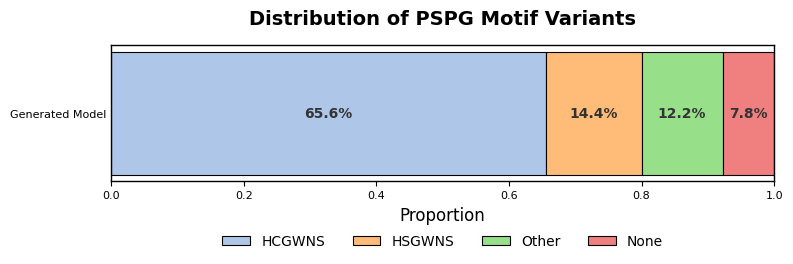

In [42]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import biotite.structure.io.pdb as pdb
import biotite.structure as struc
import biotite.sequence as seq

# ==========================================
# 1. 基础功能：从 PDB 提取序列 (稳健版)
# ==========================================
def get_sequence_from_pdb(pdb_path):
    """从 PDB 文件中提取氨基酸序列字符串"""
    try:
        file = pdb.PDBFile.read(pdb_path)
        if file.get_model_count() > 0:
            array = file.get_structure(model=1)
        else:
            array = file.get_structure()
            
        # 提取 CA 骨架
        ca_atoms = array[array.atom_name == "CA"]
        if ca_atoms.array_length() == 0: return None
        
        # 转换为序列字符串 (兼容旧版 Biotite)
        try:
            protein_seq = seq.ProteinSequence(ca_atoms.res_name)
            return str(protein_seq)
        except:
            # 备用方案
            one_letter_codes = []
            for three_letter in ca_atoms.res_name:
                try:
                    one_letter = seq.ProteinSequence.convert_letter_3to1(three_letter)
                    one_letter_codes.append(one_letter)
                except:
                    one_letter_codes.append("X")
            return "".join(one_letter_codes)
            
    except Exception as e:
        print(f"解析出错 {os.path.basename(pdb_path)}: {e}")
        return None

# ==========================================
# 2. 核心分析：PSPG 变体分类
# ==========================================
def analyze_pspg_variants(sequences):
    """统计序列中 HCGWNS, HSGWNS 和其他变体的比例"""
    total = len(sequences)
    if total == 0: return None

    # === 定义正则模式 ===
    pattern_C = r"HCGWNS"      # 经典型
    pattern_S = r"HSGWNS"      # 丝氨酸型 (重点关注)
    pattern_broad = r"H.GW.[ST]" # 宽容型骨架

    counts = {
        "HCGWNS": 0,
        "HSGWNS": 0,
        "Other": 0,
        "None": 0
    }

    for s in sequences:
        s = s.upper()
        if re.search(pattern_C, s):
            counts["HCGWNS"] += 1
        elif re.search(pattern_S, s):
            counts["HSGWNS"] += 1
        elif re.search(pattern_broad, s):
            counts["Other"] += 1
        else:
            counts["None"] += 1
            
    # 计算比例
    ratios = {k: v/total for k, v in counts.items()}
    
    # 打印文本报告
    print(f"\n--- Variant Analysis (N={total}) ---")
    print(f"  HCGWNS (Classic): {counts['HCGWNS']} ({ratios['HCGWNS']:.1%})")
    print(f"  HSGWNS (Serine) : {counts['HSGWNS']} ({ratios['HSGWNS']:.1%}) -> Focus")
    print(f"  Other Variants  : {counts['Other']} ({ratios['Other']:.1%})")
    print(f"  No Motif Found  : {counts['None']} ({ratios['None']:.1%})")
    print("-" * 30)
    
    return ratios

# ==========================================
# 3. 绘图：堆叠条形图 (Pastel Style + Black Border)
# ==========================================
def plot_stacked_variants(ratios):
    # 准备数据
    labels = ['Generated Model']
    category_names = ['HCGWNS', 'HSGWNS', 'Other', 'None']
    data = np.array([ratios[c] for c in category_names])
    
    # === 配色方案 (Pastel) ===
    # HCG (Classic) -> 淡蓝
    # HSG (Serine)  -> 淡橙 (突出显示)
    # Other         -> 淡绿
    # None          -> 淡粉 (表示缺失)
    colors = ['#AEC7E8', '#FFBB78', '#98DF8A', '#F08080']
    
    fig, ax = plt.subplots(figsize=(8, 3)) # 扁长型适合展示比例
    
    # 设置黑色边框 (Spines)
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.0)
    ax.tick_params(axis='both', colors='black')

    # 绘制堆叠图
    left = 0
    for i, (colname, color) in enumerate(zip(category_names, colors)):
        val = data[i]
        # 绘制条形
        ax.barh(labels, val, left=left, height=0.5, 
                label=colname, color=color, edgecolor='black', linewidth=0.8)
        
        # 标注数值 (如果比例太小就不标了，免得挤在一起)
        if val > 0.05: 
            # 字体颜色设为深灰，在 Pastel 背景上更清晰
            ax.text(left + val/2, 0, f"{val:.1%}", 
                    ha='center', va='center', color='#333333', fontweight='bold', fontsize=10)
        
        left += val

    # 装饰
    ax.set_title("Distribution of PSPG Motif Variants", fontsize=14, weight='bold', color='black', pad=15)
    ax.set_xlabel("Proportion", fontsize=12, color='black')
    ax.set_xlim(0, 1)
    
    # 去掉 Y 轴刻度线，只保留文字
    ax.tick_params(axis='y', length=0)
    
    # 图例放下面
    ax.legend(ncol=6, bbox_to_anchor=(0.5, -0.3), loc='upper center', frameon=False, fontsize=10)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 主程序
# ==========================================
if __name__ == "__main__":
    # 【请修改路径】
    # target_folder = "/root/REFER_PDB"
    # target_folder = "/workspace/zhangzh/ZymCTRL/OmegaFold"
    # target_folder = "/workspace/zhangzh/GENzyme/generated/all_protein"
    # target_folder = "/workspace/zhangzh/REXzyme_aa/generated/OmegaFold"
    # target_folder = "/workspace/zhangzh/ProCALM-main/generated/OmegaFold"
    target_folder = "/workspace/zhangzh/evodiff-main/output/ESM2_align_exp23_oadm_molt5_adaln_true/gent_seq/OmegaFold"

    
    
    if os.path.exists(target_folder):
        # 1. 批量读取
        pdb_files = glob.glob(os.path.join(target_folder, "*.pdb"))
        print(f"找到 {len(pdb_files)} 个文件，正在提取序列...")
        
        all_sequences = []
        for p in pdb_files:
            s = get_sequence_from_pdb(p)
            if s: all_sequences.append(s)
            
        # 2. 分析变体
        if len(all_sequences) > 0:
            ratios = analyze_pspg_variants(all_sequences)
            
            # 3. 绘图
            if ratios:
                plot_stacked_variants(ratios)
        else:
            print("未提取到有效序列。")
    else:
        print("文件夹不存在。")

# 计算pLDDT

In [56]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import biotite.structure.io.pdb as pdb
import biotite.structure as struc
from scipy.stats import gaussian_kde

def calculate_plddt_batch(pdb_dir):
    pdb_files = glob.glob(os.path.join(pdb_dir, "*.pdb"))
    if not pdb_files:
        print(f"在 {pdb_dir} 中未找到 PDB 文件。")
        return np.array([])

    print(f"在 {pdb_dir} 中找到 {len(pdb_files)} 个 PDB 文件，开始计算 pLDDT...")
    
    plddt_list = []
    
    for pdb_path in pdb_files:
        try:
            # --- 关键修改处 ---
            file = pdb.PDBFile.read(pdb_path)
            # 显式要求加载 b_factor 列
            if file.get_model_count() > 0:
                array = file.get_structure(model=1, extra_fields=['b_factor'])
            else:
                array = file.get_structure(extra_fields=['b_factor'])
            
            # 检查是否成功加载了 b_factor
            if not hasattr(array, 'b_factor'):
                # 备选方案：尝试从原子数组的注释字典中获取
                print(f"警告: {os.path.basename(pdb_path)} 未直接发现 b_factor 属性")
                continue

            # 筛选 C-alpha 原子
            ca_mask = array.atom_name == "CA"
            target_atoms = array[ca_mask]
            
            if target_atoms.array_length() == 0:
                target_atoms = array # 如果没 CA，用全原子
                
            # 计算该蛋白的平均 pLDDT
            mean_val = np.mean(target_atoms.b_factor)
            plddt_list.append(mean_val)
            
        except Exception as e:
            print(f"解析失败 {os.path.basename(pdb_path)}: {str(e)}")

    return np.array(plddt_list)

# 后续的绘图逻辑保持不变...

# ==========================================
# 主程序
# ==========================================
if __name__ == "__main__":
    # 【请修改为您的 PDB 文件夹路径】
    # target_folder = "/root/REFER_PDB"
    # target_folder = "/workspace/zhangzh/ZymCTRL/OmegaFold"
    # target_folder = "/workspace/zhangzh/GENzyme/generated/all_protein"
    # target_folder = "/workspace/zhangzh/REXzyme_aa/generated/OmegaFold"
    target_folder = "/workspace/zhangzh/ProCALM-main/generated/OmegaFold"
    # target_folder = "/workspace/zhangzh/evodiff-main/output/ESM2_align_exp23_oadm_molt5_adaln_true/gent_seq/OmegaFold"

    if os.path.exists(target_folder):
        plddts = calculate_plddt_batch(target_folder)
        
        if len(plddts) > 0:
            # 计算统计指标
            avg_plddt = np.mean(plddts)
            total_sum = np.sum(plddts)
            print("-" * 30)
            print(f"处理文件总数: {len(plddts)}")
            print(f"总分 (Sum of averages): {total_sum:.2f}")
            print(f"全局平均 pLDDT: {avg_plddt:.4f}")
            print("-" * 30)

            # --- 绘图设置 ---
            if len(plddts) > 1:
                plt.figure(figsize=(9, 6))
                
                # 1. 绘制直方图
                plt.hist(plddts, bins=15, density=True, 
                         color='#A0C4FF', edgecolor='white', alpha=0.7, label='Histogram')
                
                # 2. 添加平滑密度曲线 (KDE)
                try:
                    density = gaussian_kde(plddts)
                    # pLDDT 范围通常在 0-100
                    x_min = max(0, min(plddts) - 5)
                    x_max = min(100, max(plddts) + 5)
                    xs = np.linspace(x_min, x_max, 200)
                    plt.plot(xs, density(xs), color='#5A90E0', linewidth=2.5, label='KDE')
                except Exception:
                    print("无法绘制平滑曲线（可能数据方差为0）")
                
                # 3. 标记平均值线
                plt.axvline(avg_plddt, color='#FFADAD', linestyle='--', linewidth=2, 
                            label=f'Mean pLDDT: {avg_plddt:.2f}')

                # --- 图表美化 ---
                plt.title("Distribution of Average pLDDT Scores", fontsize=14, weight='bold')
                plt.xlabel("pLDDT Score", fontsize=12)
                plt.ylabel("Density", fontsize=12)
                plt.xlim(0, 105) # pLDDT 最高 100
                plt.grid(axis='y', linestyle=':', alpha=0.5)
                plt.legend()
                
                plt.tight_layout()
                plt.savefig("plddt_distribution.png") # 保存图片
                plt.show()
            else:
                print("样本量太少，无法绘制分布曲线。")
        else:
            print("未提取到有效的 pLDDT 数据。")
    else:
        print(f"路径不存在: {target_folder}")

路径不存在: /workspace/zhangzh/ProCALM-main/generated/OmegaFold


# 计算Novelty 和Avg. Pairwise identity

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio import pairwise2
import time
import random

def sample_fasta_sequences_reservoir(fasta_path, k=10000, seed=42):
    """
    从超大FASTA中均匀随机抽样k条序列（单次扫描，O(1)额外内存级别：存k条序列）
    返回：list[str] sequences
    """
    rng = random.Random(seed)
    reservoir = []
    n = 0

    for record in SeqIO.parse(fasta_path, "fasta"):
        seq = str(record.seq)
        n += 1
        if len(reservoir) < k:
            reservoir.append(seq)
        else:
            j = rng.randrange(n)  # [0, n-1]
            if j < k:
                reservoir[j] = seq

    if n < k:
        print(f"⚠️ ref_fasta只有 {n} 条序列，小于k={k}，将返回全部。")
    print(f"✅ 已从 {n} 条序列中均匀抽样 {min(k, n)} 条")
    return reservoir
def calculate_identity(seq1, seq2):
    """计算两条序列的全局一致性 (Normalized Identity)"""
    # 长度差异过大直接返回 0 节省计算量
    len1, len2 = len(seq1), len(seq2)
    if min(len1, len2) / max(len1, len2) < 0.2:
        return 0.0
    
    # 使用 globalxx (匹配得1分，不匹配/空位不扣分)
    # score 即为相同残基的数量
    alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    if not alignments:
        return 0.0
    score = alignments[0].score
    return score / max(len1, len2)

def main():
    # 路径设置
    ref_fasta = "/root/DATASETS/consensus.fasta"
    # gen_fasta = "/root/REFER_PDB"
    # gen_fasta = "/workspace/zhangzh/ZymCTRL/generated_seqs.fasta"
    # gen_fasta = "/workspace/zhangzh/GENzyme/generated/generated_samples_string.fasta"
    # gen_fasta = "/workspace/zhangzh/REXzyme_aa/generated/generated_seqs.fasta"
    gen_fasta = "/workspace/zhangzh/ProCALM-main/generated/generated_seqs.fasta"
    # gen_fasta = "/workspace/zhangzh/evodiff-main/output/ESM2_align_exp23_oadm_molt5_adaln_true/gent_seq/generated_samples_string.fasta"


    # 1. 加载序列
    print("正在加载序列...")
    # ref_seqs = [str(record.seq) for record in SeqIO.parse(ref_fasta, "fasta")]
    ref_seqs = sample_fasta_sequences_reservoir(ref_fasta, k=10000, seed=42)

    gen_seqs = [str(record.seq) for record in SeqIO.parse(gen_fasta, "fasta")]
    
    print(f"参考库序列数: {len(ref_seqs)}")
    print(f"生成序列数: {len(gen_seqs)}")

    # 2. 计算 Novelty
    # 对于每一条生成的序列，找到它在参考库中的“最像的亲戚”
    print("正在计算 Novelty (与参考库比对)...")
    max_identities = []
    start_time = time.time()
    
    for i, g_seq in enumerate(gen_seqs):
        best_id = 0
        for r_seq in ref_seqs:
            ident = calculate_identity(g_seq, r_seq)
            if ident > best_id:
                best_id = ident
        max_identities.append(best_id)
        if (i+1) % 10 == 0:
            print(f"进度: {i+1}/{len(gen_seqs)}...")

    novelty_scores = [1 - m for m in max_identities]
    avg_novelty = np.mean(novelty_scores)

    # 3. 计算 Avg. Pairwise Identity (内部多样性)
    print("正在计算 Avg. Pairwise Identity (生成序列内部比对)...")
    pairwise_ids = []
    n = len(gen_seqs)
    for i in range(n):
        for j in range(i + 1, n):
            ident = calculate_identity(gen_seqs[i], gen_seqs[j])
            pairwise_ids.append(ident)

    avg_pairwise_id = np.mean(pairwise_ids) if pairwise_ids else 0
    
    end_time = time.time()

    # ==========================================
    # 结果展示
    # ==========================================
    print("\n" + "="*40)
    print(f"计算耗时: {end_time - start_time:.2f} 秒")
    print(f"【Novelty】: {avg_novelty:.4f}  (越接近 1 说明越新颖)")
    print(f"【Avg. Pairwise Identity】: {avg_pairwise_id:.4f} (越低说明多样性越高)")
    print("="*40)

    # 绘图分布
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Novelty 分布图
    ax[0].hist(novelty_scores, bins=15, color='#82CAAF', edgecolor='white')
    ax[0].axvline(avg_novelty, color='red', linestyle='--', label=f'Mean: {avg_novelty:.2f}')
    ax[0].set_title("Sequence Novelty Distribution")
    ax[0].set_xlabel("Novelty (1 - Max Identity)")
    ax[0].legend()

    # Max Identity 分布图 (更直观查看是否有重复)
    ax[1].hist(max_identities, bins=15, color='#8884D8', edgecolor='white')
    ax[1].set_title("Max Identity to Reference")
    ax[1].set_xlabel("Identity")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

正在加载序列...
✅ 已从 169192 条序列中均匀抽样 10000 条
参考库序列数: 10000
生成序列数: 148
正在计算 Novelty (与参考库比对)...


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio import pairwise2
import time
import random

def sample_fasta_sequences_reservoir(fasta_path, k=10000, seed=42):
    """
    从超大FASTA中均匀随机抽样k条序列（单次扫描，O(1)额外内存级别：存k条序列）
    返回：list[str] sequences
    """
    rng = random.Random(seed)
    reservoir = []
    n = 0

    for record in SeqIO.parse(fasta_path, "fasta"):
        seq = str(record.seq)
        n += 1
        if len(reservoir) < k:
            reservoir.append(seq)
        else:
            j = rng.randrange(n)  # [0, n-1]
            if j < k:
                reservoir[j] = seq

    if n < k:
        print(f"⚠️ ref_fasta只有 {n} 条序列，小于k={k}，将返回全部。")
    print(f"✅ 已从 {n} 条序列中均匀抽样 {min(k, n)} 条")
    return reservoir
def calculate_identity(seq1, seq2):
    """计算两条序列的全局一致性 (Normalized Identity)"""
    # 长度差异过大直接返回 0 节省计算量
    len1, len2 = len(seq1), len(seq2)
    if min(len1, len2) / max(len1, len2) < 0.2:
        return 0.0
    
    # 使用 globalxx (匹配得1分，不匹配/空位不扣分)
    # score 即为相同残基的数量
    alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    if not alignments:
        return 0.0
    score = alignments[0].score
    return score / max(len1, len2)

def main():
    # 路径设置
    ref_fasta = "/root/DATASETS/consensus.fasta"
    # gen_fasta = "/root/REFER_PDB"
    gen_fasta = "/workspace/zhangzh/ZymCTRL/generated_seqs.fasta"
    # gen_fasta = "/workspace/zhangzh/GENzyme/generated/generated_samples_string.fasta"
    # gen_fasta = "/workspace/zhangzh/REXzyme_aa/generated/generated_seqs.fasta"
    # gen_fasta = "/workspace/zhangzh/evodiff-main/output/ESM2_align_exp23_oadm_molt5_adaln_true/gent_seq/generated_samples_string.fasta"


    # 1. 加载序列
    print("正在加载序列...")
    # ref_seqs = [str(record.seq) for record in SeqIO.parse(ref_fasta, "fasta")]
    ref_seqs = sample_fasta_sequences_reservoir(ref_fasta, k=10000, seed=42)

    gen_seqs = [str(record.seq) for record in SeqIO.parse(gen_fasta, "fasta")]
    
    print(f"参考库序列数: {len(ref_seqs)}")
    print(f"生成序列数: {len(gen_seqs)}")

    # 2. 计算 Novelty
    # 对于每一条生成的序列，找到它在参考库中的“最像的亲戚”
    print("正在计算 Novelty (与参考库比对)...")
    max_identities = []
    start_time = time.time()
    
    for i, g_seq in enumerate(gen_seqs):
        best_id = 0
        for r_seq in ref_seqs:
            ident = calculate_identity(g_seq, r_seq)
            if ident > best_id:
                best_id = ident
        max_identities.append(best_id)
        if (i+1) % 10 == 0:
            print(f"进度: {i+1}/{len(gen_seqs)}...")

    novelty_scores = [1 - m for m in max_identities]
    avg_novelty = np.mean(novelty_scores)

    # 3. 计算 Avg. Pairwise Identity (内部多样性)
    print("正在计算 Avg. Pairwise Identity (生成序列内部比对)...")
    pairwise_ids = []
    n = len(gen_seqs)
    for i in range(n):
        for j in range(i + 1, n):
            ident = calculate_identity(gen_seqs[i], gen_seqs[j])
            pairwise_ids.append(ident)

    avg_pairwise_id = np.mean(pairwise_ids) if pairwise_ids else 0
    
    end_time = time.time()

    # ==========================================
    # 结果展示
    # ==========================================
    print("\n" + "="*40)
    print(f"计算耗时: {end_time - start_time:.2f} 秒")
    print(f"【Novelty】: {avg_novelty:.4f}  (越接近 1 说明越新颖)")
    print(f"【Avg. Pairwise Identity】: {avg_pairwise_id:.4f} (越低说明多样性越高)")
    print("="*40)

    # 绘图分布
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Novelty 分布图
    ax[0].hist(novelty_scores, bins=15, color='#82CAAF', edgecolor='white')
    ax[0].axvline(avg_novelty, color='red', linestyle='--', label=f'Mean: {avg_novelty:.2f}')
    ax[0].set_title("Sequence Novelty Distribution")
    ax[0].set_xlabel("Novelty (1 - Max Identity)")
    ax[0].legend()

    # Max Identity 分布图 (更直观查看是否有重复)
    ax[1].hist(max_identities, bins=15, color='#8884D8', edgecolor='white')
    ax[1].set_title("Max Identity to Reference")
    ax[1].set_xlabel("Identity")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio import pairwise2
import time
import random

def sample_fasta_sequences_reservoir(fasta_path, k=10000, seed=42):
    """
    从超大FASTA中均匀随机抽样k条序列（单次扫描，O(1)额外内存级别：存k条序列）
    返回：list[str] sequences
    """
    rng = random.Random(seed)
    reservoir = []
    n = 0

    for record in SeqIO.parse(fasta_path, "fasta"):
        seq = str(record.seq)
        n += 1
        if len(reservoir) < k:
            reservoir.append(seq)
        else:
            j = rng.randrange(n)  # [0, n-1]
            if j < k:
                reservoir[j] = seq

    if n < k:
        print(f"⚠️ ref_fasta只有 {n} 条序列，小于k={k}，将返回全部。")
    print(f"✅ 已从 {n} 条序列中均匀抽样 {min(k, n)} 条")
    return reservoir
def calculate_identity(seq1, seq2):
    """计算两条序列的全局一致性 (Normalized Identity)"""
    # 长度差异过大直接返回 0 节省计算量
    len1, len2 = len(seq1), len(seq2)
    if min(len1, len2) / max(len1, len2) < 0.2:
        return 0.0
    
    # 使用 globalxx (匹配得1分，不匹配/空位不扣分)
    # score 即为相同残基的数量
    alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    if not alignments:
        return 0.0
    score = alignments[0].score
    return score / max(len1, len2)

def main():
    # 路径设置
    ref_fasta = "/root/DATASETS/consensus.fasta"
    # gen_fasta = "/root/REFER_PDB"
    gen_fasta = "/workspace/zhangzh/GENzyme/generated/generated_samples_string.fasta"
    # gen_fasta = "/workspace/zhangzh/REXzyme_aa/generated/generated_seqs.fasta"
    # gen_fasta = "/workspace/zhangzh/evodiff-main/output/ESM2_align_exp23_oadm_molt5_adaln_true/gent_seq/generated_samples_string.fasta"


    # 1. 加载序列
    print("正在加载序列...")
    # ref_seqs = [str(record.seq) for record in SeqIO.parse(ref_fasta, "fasta")]
    ref_seqs = sample_fasta_sequences_reservoir(ref_fasta, k=10000, seed=42)

    gen_seqs = [str(record.seq) for record in SeqIO.parse(gen_fasta, "fasta")]
    
    print(f"参考库序列数: {len(ref_seqs)}")
    print(f"生成序列数: {len(gen_seqs)}")

    # 2. 计算 Novelty
    # 对于每一条生成的序列，找到它在参考库中的“最像的亲戚”
    print("正在计算 Novelty (与参考库比对)...")
    max_identities = []
    start_time = time.time()
    
    for i, g_seq in enumerate(gen_seqs):
        best_id = 0
        for r_seq in ref_seqs:
            ident = calculate_identity(g_seq, r_seq)
            if ident > best_id:
                best_id = ident
        max_identities.append(best_id)
        if (i+1) % 10 == 0:
            print(f"进度: {i+1}/{len(gen_seqs)}...")

    novelty_scores = [1 - m for m in max_identities]
    avg_novelty = np.mean(novelty_scores)

    # 3. 计算 Avg. Pairwise Identity (内部多样性)
    print("正在计算 Avg. Pairwise Identity (生成序列内部比对)...")
    pairwise_ids = []
    n = len(gen_seqs)
    for i in range(n):
        for j in range(i + 1, n):
            ident = calculate_identity(gen_seqs[i], gen_seqs[j])
            pairwise_ids.append(ident)

    avg_pairwise_id = np.mean(pairwise_ids) if pairwise_ids else 0
    
    end_time = time.time()

    # ==========================================
    # 结果展示
    # ==========================================
    print("\n" + "="*40)
    print(f"计算耗时: {end_time - start_time:.2f} 秒")
    print(f"【Novelty】: {avg_novelty:.4f}  (越接近 1 说明越新颖)")
    print(f"【Avg. Pairwise Identity】: {avg_pairwise_id:.4f} (越低说明多样性越高)")
    print("="*40)

    # 绘图分布
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Novelty 分布图
    ax[0].hist(novelty_scores, bins=15, color='#82CAAF', edgecolor='white')
    ax[0].axvline(avg_novelty, color='red', linestyle='--', label=f'Mean: {avg_novelty:.2f}')
    ax[0].set_title("Sequence Novelty Distribution")
    ax[0].set_xlabel("Novelty (1 - Max Identity)")
    ax[0].legend()

    # Max Identity 分布图 (更直观查看是否有重复)
    ax[1].hist(max_identities, bins=15, color='#8884D8', edgecolor='white')
    ax[1].set_title("Max Identity to Reference")
    ax[1].set_xlabel("Identity")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio import pairwise2
import time
import random

def sample_fasta_sequences_reservoir(fasta_path, k=10000, seed=42):
    """
    从超大FASTA中均匀随机抽样k条序列（单次扫描，O(1)额外内存级别：存k条序列）
    返回：list[str] sequences
    """
    rng = random.Random(seed)
    reservoir = []
    n = 0

    for record in SeqIO.parse(fasta_path, "fasta"):
        seq = str(record.seq)
        n += 1
        if len(reservoir) < k:
            reservoir.append(seq)
        else:
            j = rng.randrange(n)  # [0, n-1]
            if j < k:
                reservoir[j] = seq

    if n < k:
        print(f"⚠️ ref_fasta只有 {n} 条序列，小于k={k}，将返回全部。")
    print(f"✅ 已从 {n} 条序列中均匀抽样 {min(k, n)} 条")
    return reservoir
def calculate_identity(seq1, seq2):
    """计算两条序列的全局一致性 (Normalized Identity)"""
    # 长度差异过大直接返回 0 节省计算量
    len1, len2 = len(seq1), len(seq2)
    if min(len1, len2) / max(len1, len2) < 0.2:
        return 0.0
    
    # 使用 globalxx (匹配得1分，不匹配/空位不扣分)
    # score 即为相同残基的数量
    alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    if not alignments:
        return 0.0
    score = alignments[0].score
    return score / max(len1, len2)

def main():
    # 路径设置
    ref_fasta = "/root/DATASETS/consensus.fasta"
    # gen_fasta = "/root/REFER_PDB"
    gen_fasta = "/workspace/zhangzh/REXzyme_aa/generated/generated_seqs.fasta"
    # gen_fasta = "/workspace/zhangzh/evodiff-main/output/ESM2_align_exp23_oadm_molt5_adaln_true/gent_seq/generated_samples_string.fasta"


    # 1. 加载序列
    print("正在加载序列...")
    # ref_seqs = [str(record.seq) for record in SeqIO.parse(ref_fasta, "fasta")]
    ref_seqs = sample_fasta_sequences_reservoir(ref_fasta, k=10000, seed=42)

    gen_seqs = [str(record.seq) for record in SeqIO.parse(gen_fasta, "fasta")]
    
    print(f"参考库序列数: {len(ref_seqs)}")
    print(f"生成序列数: {len(gen_seqs)}")

    # 2. 计算 Novelty
    # 对于每一条生成的序列，找到它在参考库中的“最像的亲戚”
    print("正在计算 Novelty (与参考库比对)...")
    max_identities = []
    start_time = time.time()
    
    for i, g_seq in enumerate(gen_seqs):
        best_id = 0
        for r_seq in ref_seqs:
            ident = calculate_identity(g_seq, r_seq)
            if ident > best_id:
                best_id = ident
        max_identities.append(best_id)
        if (i+1) % 10 == 0:
            print(f"进度: {i+1}/{len(gen_seqs)}...")

    novelty_scores = [1 - m for m in max_identities]
    avg_novelty = np.mean(novelty_scores)

    # 3. 计算 Avg. Pairwise Identity (内部多样性)
    print("正在计算 Avg. Pairwise Identity (生成序列内部比对)...")
    pairwise_ids = []
    n = len(gen_seqs)
    for i in range(n):
        for j in range(i + 1, n):
            ident = calculate_identity(gen_seqs[i], gen_seqs[j])
            pairwise_ids.append(ident)

    avg_pairwise_id = np.mean(pairwise_ids) if pairwise_ids else 0
    
    end_time = time.time()

    # ==========================================
    # 结果展示
    # ==========================================
    print("\n" + "="*40)
    print(f"计算耗时: {end_time - start_time:.2f} 秒")
    print(f"【Novelty】: {avg_novelty:.4f}  (越接近 1 说明越新颖)")
    print(f"【Avg. Pairwise Identity】: {avg_pairwise_id:.4f} (越低说明多样性越高)")
    print("="*40)

    # 绘图分布
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Novelty 分布图
    ax[0].hist(novelty_scores, bins=15, color='#82CAAF', edgecolor='white')
    ax[0].axvline(avg_novelty, color='red', linestyle='--', label=f'Mean: {avg_novelty:.2f}')
    ax[0].set_title("Sequence Novelty Distribution")
    ax[0].set_xlabel("Novelty (1 - Max Identity)")
    ax[0].legend()

    # Max Identity 分布图 (更直观查看是否有重复)
    ax[1].hist(max_identities, bins=15, color='#8884D8', edgecolor='white')
    ax[1].set_title("Max Identity to Reference")
    ax[1].set_xlabel("Identity")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio import pairwise2
import time
import random

def sample_fasta_sequences_reservoir(fasta_path, k=10000, seed=42):
    """
    从超大FASTA中均匀随机抽样k条序列（单次扫描，O(1)额外内存级别：存k条序列）
    返回：list[str] sequences
    """
    rng = random.Random(seed)
    reservoir = []
    n = 0

    for record in SeqIO.parse(fasta_path, "fasta"):
        seq = str(record.seq)
        n += 1
        if len(reservoir) < k:
            reservoir.append(seq)
        else:
            j = rng.randrange(n)  # [0, n-1]
            if j < k:
                reservoir[j] = seq

    if n < k:
        print(f"⚠️ ref_fasta只有 {n} 条序列，小于k={k}，将返回全部。")
    print(f"✅ 已从 {n} 条序列中均匀抽样 {min(k, n)} 条")
    return reservoir
def calculate_identity(seq1, seq2):
    """计算两条序列的全局一致性 (Normalized Identity)"""
    # 长度差异过大直接返回 0 节省计算量
    len1, len2 = len(seq1), len(seq2)
    if min(len1, len2) / max(len1, len2) < 0.2:
        return 0.0
    
    # 使用 globalxx (匹配得1分，不匹配/空位不扣分)
    # score 即为相同残基的数量
    alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    if not alignments:
        return 0.0
    score = alignments[0].score
    return score / max(len1, len2)

def main():
    # 路径设置
    ref_fasta = "/root/DATASETS/consensus.fasta"
    # gen_fasta = "/root/REFER_PDB"
    gen_fasta = "/workspace/zhangzh/evodiff-main/output/ESM2_align_exp23_oadm_molt5_adaln_true/gent_seq/generated_samples_string.fasta"

    # 1. 加载序列
    print("正在加载序列...")
    # ref_seqs = [str(record.seq) for record in SeqIO.parse(ref_fasta, "fasta")]
    ref_seqs = sample_fasta_sequences_reservoir(ref_fasta, k=10000, seed=42)

    gen_seqs = [str(record.seq) for record in SeqIO.parse(gen_fasta, "fasta")]
    
    print(f"参考库序列数: {len(ref_seqs)}")
    print(f"生成序列数: {len(gen_seqs)}")

    # 2. 计算 Novelty
    # 对于每一条生成的序列，找到它在参考库中的“最像的亲戚”
    print("正在计算 Novelty (与参考库比对)...")
    max_identities = []
    start_time = time.time()
    
    for i, g_seq in enumerate(gen_seqs):
        best_id = 0
        for r_seq in ref_seqs:
            ident = calculate_identity(g_seq, r_seq)
            if ident > best_id:
                best_id = ident
        max_identities.append(best_id)
        if (i+1) % 10 == 0:
            print(f"进度: {i+1}/{len(gen_seqs)}...")

    novelty_scores = [1 - m for m in max_identities]
    avg_novelty = np.mean(novelty_scores)

    # 3. 计算 Avg. Pairwise Identity (内部多样性)
    print("正在计算 Avg. Pairwise Identity (生成序列内部比对)...")
    pairwise_ids = []
    n = len(gen_seqs)
    for i in range(n):
        for j in range(i + 1, n):
            ident = calculate_identity(gen_seqs[i], gen_seqs[j])
            pairwise_ids.append(ident)

    avg_pairwise_id = np.mean(pairwise_ids) if pairwise_ids else 0
    
    end_time = time.time()

    # ==========================================
    # 结果展示
    # ==========================================
    print("\n" + "="*40)
    print(f"计算耗时: {end_time - start_time:.2f} 秒")
    print(f"【Novelty】: {avg_novelty:.4f}  (越接近 1 说明越新颖)")
    print(f"【Avg. Pairwise Identity】: {avg_pairwise_id:.4f} (越低说明多样性越高)")
    print("="*40)

    # 绘图分布
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Novelty 分布图
    ax[0].hist(novelty_scores, bins=15, color='#82CAAF', edgecolor='white')
    ax[0].axvline(avg_novelty, color='red', linestyle='--', label=f'Mean: {avg_novelty:.2f}')
    ax[0].set_title("Sequence Novelty Distribution")
    ax[0].set_xlabel("Novelty (1 - Max Identity)")
    ax[0].legend()

    # Max Identity 分布图 (更直观查看是否有重复)
    ax[1].hist(max_identities, bins=15, color='#8884D8', edgecolor='white')
    ax[1].set_title("Max Identity to Reference")
    ax[1].set_xlabel("Identity")
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

# 计算AA distribution

In [ ]:
import os
from Bio import SeqIO
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def get_aa_distribution(fasta_path):
    """统计 FASTA 文件中 20 种氨基酸的百分比频率"""
    aa_list = list("ACDEFGHIKLMNPQRSTVWY")
    counts = {aa: 0 for aa in aa_list}
    total_len = 0
    
    if not os.path.exists(fasta_path):
        return None

    for record in SeqIO.parse(fasta_path, "fasta"):
        seq = str(record.seq).upper()
        for aa in aa_list:
            counts[aa] += seq.count(aa)
        total_len += len(seq)
    
    # 转换为百分比
    if total_len == 0: return None
    return {aa: (count / total_len) * 100 for aa, count in counts.items()}

# ==========================================
# 配置与运行
# ==========================================

ref_fasta = "/root/DATASETS/consensus.fasta"
tasks = {
    "Reference": ref_fasta,
    "ZymCTRL": "/workspace/zhangzh/ZymCTRL/generated_seqs.fasta",
    "GENzyme": "/workspace/zhangzh/GENzyme/generated/generated_samples_string.fasta",
    "REXzyme": "/workspace/zhangzh/REXzyme_aa/generated/generated_seqs.fasta",
    "ProCALM": "/workspace/zhangzh/ProCALM-main/generated/generated_seqs.fasta",
    "TransGen": "/workspace/zhangzh/evodiff-main/output/ESM2_align_exp23_oadm_molt5_adaln_true/gent_seq/generated_samples_string.fasta"
}
# 自定义高级色系 (莫兰迪风格)
custom_colors = {
    "Reference": "#8498AB", # 深灰蓝
    "ZymCTRL":   "#5CB0C3", # 藕粉灰
    "GENzyme":   "#C1E0DB", # 浅杏灰
    "REXzyme":   "#CCD376", # 雾霾蓝
    "ProCALM":   "#F5BE8F", # 鼠尾草绿
    "TransGen":   "#FDDED7"  # 珊瑚灰
}
all_dist = {}
for name, path in tasks.items():
    dist = get_aa_distribution(path)
    if dist:
        all_dist[name] = dist

# 转换为 DataFrame 方便绘图
df = pd.DataFrame(all_dist)
aa_order = list("ACDEFGHIKLMNPQRSTVWY")
df = df.reindex(aa_order)

# ==========================================
# 绘图展示
# ==========================================

# 1. 绘制对比柱状图
plt.figure(figsize=(16, 8))
x = np.arange(len(aa_order))
width = 0.15 # 柱子宽度

for i, (name, color) in enumerate(zip(df.columns, plt.cm.tab10.colors)):
    plt.bar(x + i*width, df[name], width, label=name, color=custom_colors[name])

plt.title("Amino Acid Distribution: Generated vs Reference", fontsize=16, weight='bold')
plt.xlabel("Amino Acid", fontsize=12)
plt.ylabel("Frequency (%)", fontsize=12)
plt.xticks(x + width * (len(df.columns)/2), aa_order)
plt.legend()
# plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.grid(False)
# 2. 额外计算一个 KL 散度或皮尔逊相关系数（可选，衡量分布相似度）
print("--- AA Distribution Similarity (to Reference) ---")
ref_data = df["Reference"]
for col in df.columns:
    if col != "Reference":
        correlation = np.corrcoef(ref_data, df[col])[0, 1]
        print(f"{col:<10}: Pearson Correlation = {correlation:.4f}")

plt.tight_layout()
plt.savefig("aa_distribution_comparison.png")
plt.show()